In [ ]:
#Install packages
!pip install -q statsmodels openpyxl mlxtend

#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

#Output folder
import os
PROJECT_DIR = '/content/drive/MyDrive/PRT564_Project'
OUTPUT_DIR = f'{PROJECT_DIR}/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Project folder: {PROJECT_DIR}')
print(f'Outputs will save to: {OUTPUT_DIR}')

Mounted at /content/drive
Project folder: /content/drive/MyDrive/PRT564_Project
Outputs will save to: /content/drive/MyDrive/PRT564_Project/outputs


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Statistical modelling
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

#Scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Hypothesis testing
from scipy import stats

#Quality of life
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

#Path to the merged dataset
DATA_PATH = f'{PROJECT_DIR}/quarterly_regression_merged_dataset.xlsx'
print('Ready to analyse. Data path:', DATA_PATH)

Ready to analyse. Data path: /content/drive/MyDrive/PRT564_Project/quarterly_regression_merged_dataset.xlsx


In [ ]:
#Load main panel
df = pd.read_excel(DATA_PATH, sheet_name='State_Qtr_SA_NoPop', header=2)
df.columns = df.columns.str.strip()

for c in df.columns:
    if c not in ['Quarter', 'Quarter_End', 'State']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

#sort by (State, Quarter_End)
df = df.sort_values(['State', 'Quarter_End']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'States: {sorted(df["State"].unique())}')
print(f'Time range: {df["Quarter"].min()} to {df["Quarter"].max()}')
print(f'\nObservations per state:')
print(df.groupby('State').size())
print(f'\nMissing values (showing non-zero only):')
missing = df.isna().sum()
print(missing[missing > 0])
print(f'\nFirst 3 rows:')
df.head(3)

Shape: (672, 15)
States: ['NSW', 'QLD', 'SA', 'TAS', 'VIC', 'WA']
Time range: 1997Q3 to 2025Q2

Observations per state:
State
NSW    112
QLD    112
SA     112
TAS    112
VIC    112
WA     112
dtype: int64

Missing values (showing non-zero only):
Retail_Turnover_QoQ_Pct       6
Unemployment_QoQ_Pct          6
CPI_QoQ_Pct                   6
Cash_Rate_QoQ_Pct             6
WPI_QoQ_Pct                   6
State_Final_Demand_QoQ_Pct    6
dtype: int64

First 3 rows:


,Quarter,Quarter_End,State,Retail_Turnover_CVM_SA,Retail_Turnover_QoQ_Pct,Unemployment_Rate_QtrAvg_SA,Unemployment_QoQ_Pct,CPI_All_Groups_Index,CPI_QoQ_Pct,Cash_Rate_QtrAvg,Cash_Rate_QoQ_Pct,WPI_Index_SA,WPI_QoQ_Pct,State_Final_Demand_SA,State_Final_Demand_QoQ_Pct
0,1997Q3,1997-09-30,NSW,15648.9,NaN,7.759386,NaN,46.28,NaN,5.152174,NaN,66.6,NaN,94122,NaN
1,1997Q4,1997-12-31,NSW,15804.2,0.992402,7.453965,-3.936145,46.39,0.237684,5.000000,-2.953586,67.2,0.900901,97053,3.114043
2,1998Q1,1998-03-31,NSW,15791.8,-0.078460,7.257086,-2.641261,46.51,0.258676,5.000000,0.000000,67.8,0.892857,97387,0.344142


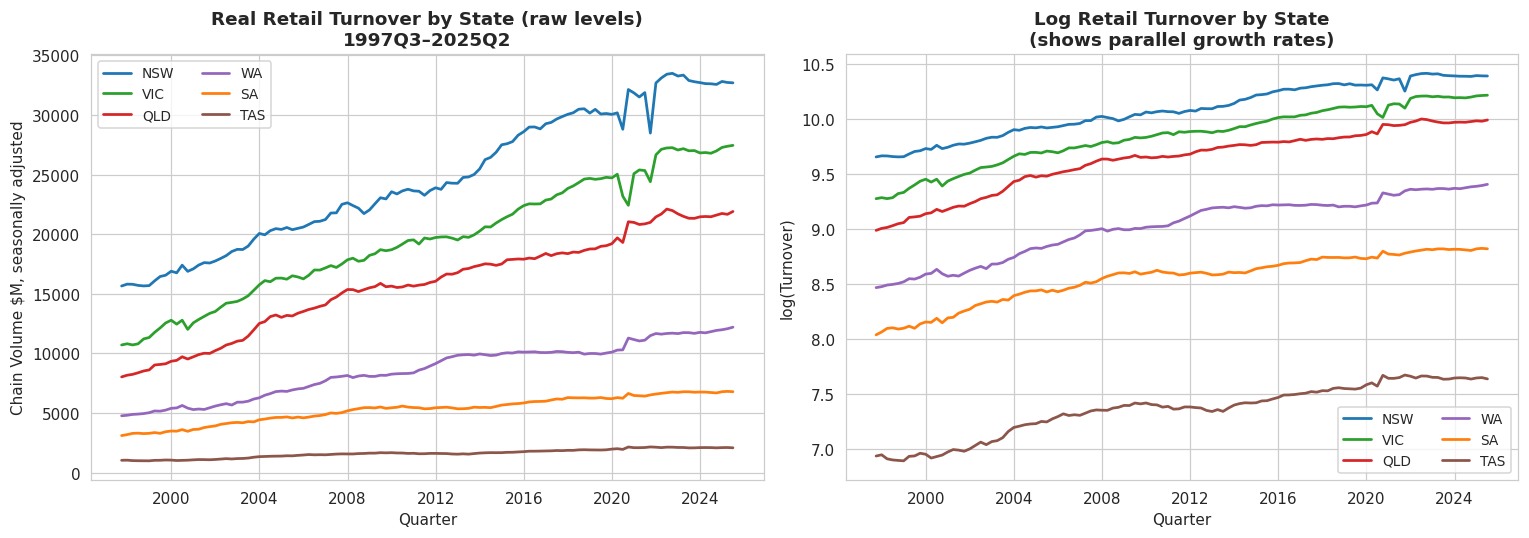

In [ ]:
#Colour legend as per state
STATE_COLOURS = {
    'NSW':'#1f77b4',  # blue
    'VIC':'#2ca02c',  # green
    'QLD':'#d62728',  # red
    'SA' :'#ff7f0e',  # orange
    'WA' :'#9467bd',  # purple
    'TAS':'#8c564b',  # brown
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for state in ['NSW','VIC','QLD','WA','SA','TAS']:
    sub = df[df['State'] == state]
    ax1.plot(sub['Quarter_End'], sub['Retail_Turnover_CVM_SA'],
             label=state, linewidth=1.8, color=STATE_COLOURS[state])
    ax2.plot(sub['Quarter_End'], np.log(sub['Retail_Turnover_CVM_SA']),
             label=state, linewidth=1.8, color=STATE_COLOURS[state])

ax1.set_title('Real Retail Turnover by State (raw levels)\n1997Q3–2025Q2',
              fontweight='bold', fontsize=12)
ax1.set_ylabel('Chain Volume $M, seasonally adjusted')
ax1.set_xlabel('Quarter')
ax1.legend(loc='upper left', ncol=2, fontsize=9)

ax2.set_title('Log Retail Turnover by State\n(shows parallel growth rates)',
              fontweight='bold', fontsize=12)
ax2.set_ylabel('log(Turnover)')
ax2.set_xlabel('Quarter')
ax2.legend(loc='lower right', ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig1_turnover_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

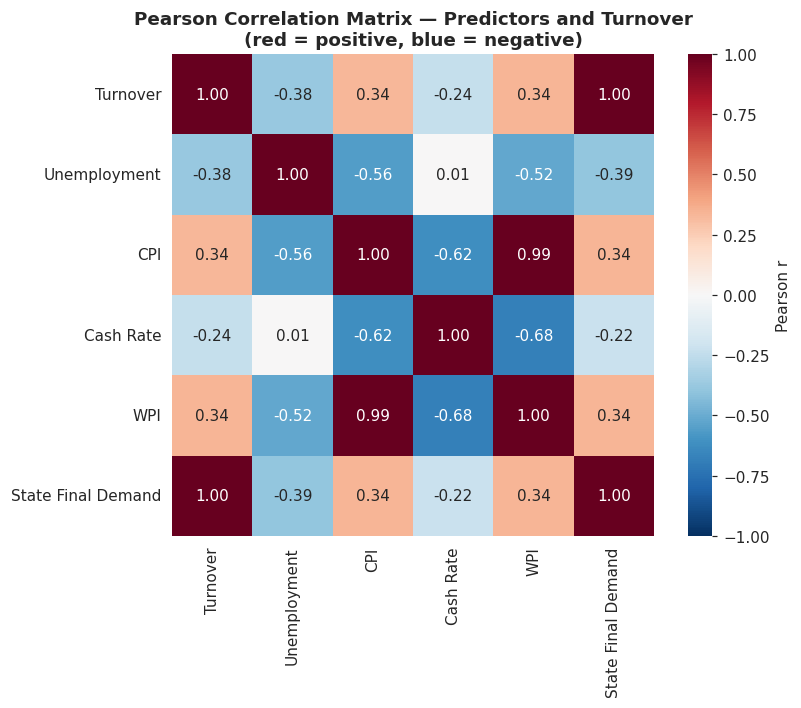


Correlations with Turnover (ranked by absolute value):
  State Final Demand: r = +0.997
  Unemployment: r = -0.378
  WPI: r = +0.338
  CPI: r = +0.335
  Cash Rate: r = -0.235


In [ ]:
corr_vars = ['Retail_Turnover_CVM_SA', 'Unemployment_Rate_QtrAvg_SA',
             'CPI_All_Groups_Index', 'Cash_Rate_QtrAvg',
             'WPI_Index_SA', 'State_Final_Demand_SA']
corr_labels = ['Turnover', 'Unemployment', 'CPI', 'Cash Rate', 'WPI', 'State Final Demand']

corr = df[corr_vars].corr()
corr.columns = corr_labels
corr.index = corr_labels

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            vmin=-1, vmax=1, cbar_kws={'label': 'Pearson r'})
plt.title('Pearson Correlation Matrix — Predictors and Turnover\n(red = positive, blue = negative)',
          fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelations with Turnover (ranked by absolute value):')
turnover_corr = corr.loc['Turnover'].drop('Turnover').abs().sort_values(ascending=False)
for var, r in turnover_corr.items():
    raw_r = corr.loc['Turnover', var]
    print(f'  {var}: r = {raw_r:+.3f}')

In [ ]:
#1. Log-transform the outcome
df['log_turnover'] = np.log(df['Retail_Turnover_CVM_SA'])

#2. Create state dummies (NSW dropped as reference)
state_dummies = pd.get_dummies(df['State'], prefix='State', drop_first=True, dtype=int)
df = pd.concat([df, state_dummies], axis=1)
state_cols = list(state_dummies.columns)
print('Created dummy columns:', state_cols)
print('(NSW is the reference state — all other state coefficients are relative to NSW)')

#3. Build 1 and 2 quarter lags
lag_vars = ['Unemployment_Rate_QtrAvg_SA', 'Cash_Rate_QtrAvg',
            'CPI_All_Groups_Index', 'State_Final_Demand_SA']

for v in lag_vars:
    df[f'{v}_L1'] = df.groupby('State')[v].shift(1)  # 1 quarter ago
    df[f'{v}_L2'] = df.groupby('State')[v].shift(2)  # 2 quarters ago

#Build a separate dataframe for models that use lags (drops first 2 quarters per state)
lag_cols = [f'{v}_L1' for v in lag_vars] + [f'{v}_L2' for v in lag_vars]
df_lagged = df.dropna(subset=lag_cols).reset_index(drop=True)

print(f'\nMain panel: {df.shape[0]} rows')
print(f'Lagged panel (drops first 2 quarters per state): {df_lagged.shape[0]} rows')
print(f'  Difference: 6 states × 2 lost quarters = {df.shape[0] - df_lagged.shape[0]} rows')

Created dummy columns: ['State_QLD', 'State_SA', 'State_TAS', 'State_VIC', 'State_WA']
(NSW is the reference state — all other state coefficients are relative to NSW)

Main panel: 672 rows
Lagged panel (drops first 2 quarters per state): 660 rows
  Difference: 6 states × 2 lost quarters = 12 rows


In [ ]:
def compute_vif(X):
    '''Compute VIF for each predictor, including the constant.'''
    Xc = sm.add_constant(X).astype(float)
    vif_rows = []
    for i, col in enumerate(Xc.columns):
        vif_rows.append({
            'Variable': col,
            'VIF': variance_inflation_factor(Xc.values, i)
        })
    return pd.DataFrame(vif_rows)

macro_vars = ['Unemployment_Rate_QtrAvg_SA', 'CPI_All_Groups_Index',
              'Cash_Rate_QtrAvg', 'WPI_Index_SA', 'State_Final_Demand_SA']

vif_table = compute_vif(df[macro_vars])
print('VIF for raw macro predictors:')
print(vif_table.round(2).to_string(index=False))

print('''
Interpretation:
  - VIF > 10 = severe multicollinearity
  - VIF 5-10 = moderate concern
  - VIF < 5  = low concern

If CPI and WPI show very high VIFs, this is expected, they are both
national price indices trending upward together. Our mitigation strategy:
  1. State fixed effects (added in Section 7) absorb the shared national trend
  2. A PCA robustness check in Section 12 re-runs the model with orthogonal
     principal components, eliminating multicollinearity entirely
''')

VIF for raw macro predictors:
                   Variable    VIF
                      const 258.58
Unemployment_Rate_QtrAvg_SA   2.21
       CPI_All_Groups_Index 169.70
           Cash_Rate_QtrAvg   4.74
               WPI_Index_SA 196.81
      State_Final_Demand_SA   1.25

Interpretation:
  - VIF > 10 = severe multicollinearity
  - VIF 5-10 = moderate concern
  - VIF < 5  = low concern

If CPI and WPI show very high VIFs, this is expected, they are both
national price indices trending upward together. Our mitigation strategy:
  1. State fixed effects (added in Section 7) absorb the shared national trend
  2. A PCA robustness check in Section 12 re-runs the model with orthogonal
     principal components, eliminating multicollinearity entirely



In [ ]:
#Hypothesis tested by M1

#H0: All five macro coefficients equal zero (Macro variables jointly have no effect on turnover)
#H1: At least one coefficient is non-zero Decision rule: Reject H0 if the F-test p-value < 0.05


y = df['log_turnover']
predictors_m1 = macro_vars

X1 = sm.add_constant(df[predictors_m1].astype(float))
m1 = sm.OLS(y, X1).fit()
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:           log_turnover   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     823.8
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          2.41e-282
Time:                        01:22:43   Log-Likelihood:                -264.88
No. Observations:                 672   AIC:                             541.8
Df Residuals:                     666   BIC:                             568.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [ ]:
#Hypothesis tested by M2 vs M1 (nested F-test)

#H0: The five state dummies jointly have no effect (All λ's equal zero) H1: At least one state has a basline different from NSW

predictors_m2 = macro_vars + state_cols
X2 = sm.add_constant(df[predictors_m2].astype(float))
m2 = sm.OLS(y, X2).fit()
print(m2.summary())

#Nested F-test: is M2 significantly better than M1?
f_stat, p_val, df_diff = m2.compare_f_test(m1)
print(f'\n=== NESTED F-TEST: Model 2 vs Model 1 ===')
print(f'F-statistic: {f_stat:.3f}')
print(f'p-value: {p_val:.2e}')
print(f'Additional degrees of freedom used: {int(df_diff)}')
print(f'\nR² change: {m1.rsquared:.4f} (M1) → {m2.rsquared:.4f} (M2)')
print(f'Adj R² change: {m1.rsquared_adj:.4f} (M1) → {m2.rsquared_adj:.4f} (M2)')

                            OLS Regression Results                            
Dep. Variable:           log_turnover   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 2.611e+04
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:25:35   Log-Likelihood:                 1082.3
No. Observations:                 672   AIC:                            -2143.
Df Residuals:                     661   BIC:                            -2093.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [ ]:
#Hypothesis tested by M3 vs M2

#H0: All five State x CashRate interaction coefficients are zero (states respond identically to cash rate)
#H1: At least one state has a different cash-rate sensitivity from NSW

#interaction terms
for s in state_cols:
    df[f'{s}_x_CashRate'] = df[s] * df['Cash_Rate_QtrAvg']

interaction_cols = [f'{s}_x_CashRate' for s in state_cols]
predictors_m3 = predictors_m2 + interaction_cols

X3 = sm.add_constant(df[predictors_m3].astype(float))
m3 = sm.OLS(y, X3).fit()
print(m3.summary())

#Nested F-test
f_stat, p_val, df_diff = m3.compare_f_test(m2)
print(f'\n=== NESTED F-TEST: Model 3 vs Model 2 ===')
print(f'F-statistic: {f_stat:.3f}')
print(f'p-value: {p_val:.2e}')
print(f'Additional degrees of freedom: {int(df_diff)}')
print(f'\nInterpretation: if p < 0.05, state-specific cash-rate responses are statistically real.')

                            OLS Regression Results                            
Dep. Variable:           log_turnover   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 2.090e+04
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:27:07   Log-Likelihood:                 1146.2
No. Observations:                 672   AIC:                            -2260.
Df Residuals:                     656   BIC:                            -2188.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

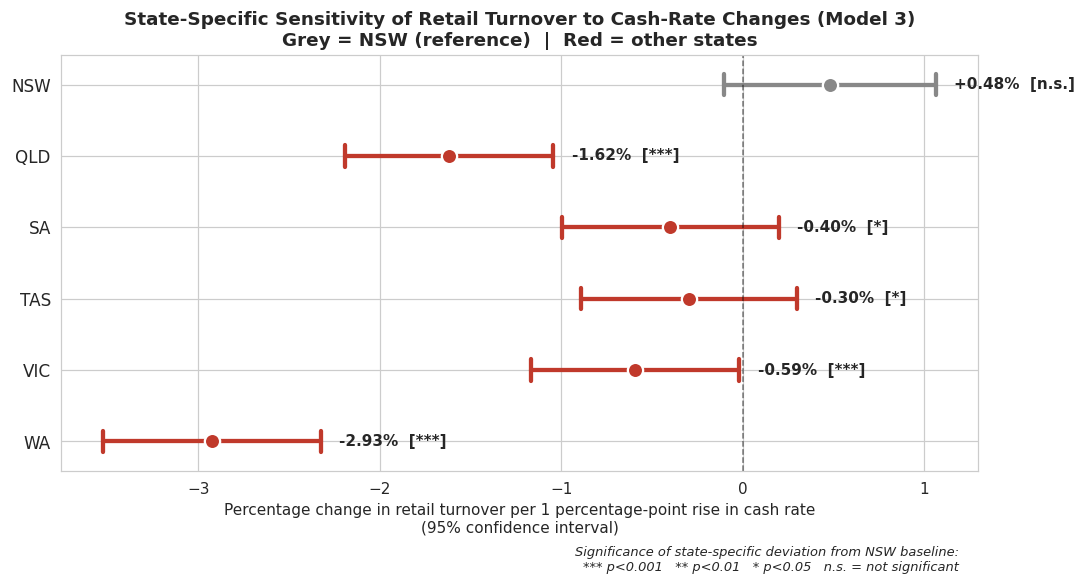


Numerical summary:
  NSW: +0.48%  [95% CI: -0.10% to +1.06%]  interaction p = —
  QLD: -1.62%  [95% CI: -2.19% to -1.04%]  interaction p = 0.0000
  SA: -0.40%  [95% CI: -1.00% to +0.20%]  interaction p = 0.0154
  TAS: -0.30%  [95% CI: -0.89% to +0.30%]  interaction p = 0.0396
  VIC: -0.59%  [95% CI: -1.17% to -0.02%]  interaction p = 0.0008
  WA: -2.93%  [95% CI: -3.53% to -2.33%]  interaction p = 0.0000


In [ ]:
#Compute each state's total cash-rate effect with confidence intervals
states_order = ['NSW', 'QLD', 'SA', 'TAS', 'VIC', 'WA']
cov = m3.cov_params()
ref_coef = m3.params['Cash_Rate_QtrAvg']     #NSW's effect
ref_se = m3.bse['Cash_Rate_QtrAvg']

results = []
for s in states_order:
    if s == 'NSW':
        eff = ref_coef
        se = ref_se
        p_interaction = None  #No interaction for reference
        p_display = m3.pvalues['Cash_Rate_QtrAvg']
    else:
        key = f'State_{s}_x_CashRate'
        eff = ref_coef + m3.params[key]
        #Var of sum of two coefficients
        var = (cov.loc['Cash_Rate_QtrAvg','Cash_Rate_QtrAvg']
               + cov.loc[key, key]
               + 2 * cov.loc['Cash_Rate_QtrAvg', key])
        se = np.sqrt(var)
        p_interaction = m3.pvalues[key]
        p_display = p_interaction
    results.append({'state': s, 'eff': eff, 'se': se,
                    'ci_low': eff - 1.96*se, 'ci_high': eff + 1.96*se,
                    'p_interaction': p_interaction, 'p_display': p_display})

#Build the plot
fig, ax = plt.subplots(figsize=(10, 5.5))

for i, r in enumerate(results):
    is_ref = (r['state'] == 'NSW')
    colour = '#888888' if is_ref else '#c0392b'

    eff_pct = r['eff'] * 100
    lo_pct = r['ci_low'] * 100
    hi_pct = r['ci_high'] * 100

    #Draw the CI bar
    ax.plot([lo_pct, hi_pct], [i, i], color=colour, linewidth=2.8)
    ax.plot([lo_pct, lo_pct], [i - 0.15, i + 0.15], color=colour, linewidth=2.8)
    ax.plot([hi_pct, hi_pct], [i - 0.15, i + 0.15], color=colour, linewidth=2.8)
    ax.scatter(eff_pct, i, s=100, color=colour, zorder=10,
               edgecolor='white', linewidth=1.5)

    #Significance marker based on interaction p-value (NSW uses its own test)
    pv = r['p_display']
    sig = '***' if pv < 0.001 else '**' if pv < 0.01 else '*' if pv < 0.05 else 'n.s.'

    ax.annotate(f'{eff_pct:+.2f}%  [{sig}]',
                xy=(hi_pct, i), xytext=(12, 0),
                textcoords='offset points', va='center',
                fontweight='bold', fontsize=10)

ax.axvline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
ax.set_yticks(range(len(states_order)))
ax.set_yticklabels(states_order, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Percentage change in retail turnover per 1 percentage-point rise in cash rate\n(95% confidence interval)',
              fontsize=10)
ax.set_title('State-Specific Sensitivity of Retail Turnover to Cash-Rate Changes (Model 3)\nGrey = NSW (reference)  |  Red = other states',
             fontweight='bold', fontsize=12)

#Legend for significance markers
ax.text(0.98, -0.18,
        'Significance of state-specific deviation from NSW baseline:\n'
        '*** p<0.001   ** p<0.01   * p<0.05   n.s. = not significant',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=8.5, style='italic')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig3_state_cashrate_effects.png', dpi=150, bbox_inches='tight')
plt.show()

#Print table for the presentation
print('\nNumerical summary:')
for r in results:
    eff_pct = r['eff'] * 100
    lo_pct = r['ci_low'] * 100
    hi_pct = r['ci_high'] * 100
    pstr = f'{r["p_interaction"]:.4f}' if r['p_interaction'] is not None else '—'
    print(f'  {r["state"]}: {eff_pct:+.2f}%  [95% CI: {lo_pct:+.2f}% to {hi_pct:+.2f}%]  interaction p = {pstr}')

In [ ]:
import pandas as pd

#Hypothesis tested by M4 vs M3

#H0: All 8 lag coefficients (2 lags x 4 variables) are zero
#H1: At least one lag coefficient is non-zero

# Re-create df_lagged to ensure it includes interaction terms
# df_lagged was created before interaction terms were added to df
# `lag_cols` was defined in cell AMJxC8gLvuF8 and is available globally
# `df` now contains interaction terms from cell z01-aFSxyyIV
df_lagged = df.dropna(subset=lag_cols).reset_index(drop=True)

predictors_m4 = predictors_m3 + lag_cols

X4 = sm.add_constant(df_lagged[predictors_m4].astype(float))
y_lag = df_lagged['log_turnover']
m4 = sm.OLS(y_lag, X4).fit()

# Refit M3 on the same (slightly reduced) sample for a fair F-test
X3_same = sm.add_constant(df_lagged[predictors_m3].astype(float))
m3_same = sm.OLS(y_lag, X3_same).fit()

f_stat, p_val, df_diff = m4.compare_f_test(m3_same)
print(f'=== NESTED F-TEST: Model 4 vs Model 3 (same sample) ===')
print(f'F-statistic: {f_stat:.3f}')
print(f'p-value: {p_val:.2e}')
print(f'Additional degrees of freedom used: {int(df_diff)}')
print(f'\nR² change: {m3_same.rsquared:.4f} → {m4.rsquared:.4f}')

#Show only the lag coefficients for interpretation
print('\n=== LAG COEFFICIENT TABLE ===')
lag_display = []
for var, pretty in [('Unemployment_Rate_QtrAvg_SA', 'Unemployment'),
                    ('Cash_Rate_QtrAvg', 'Cash Rate'),
                    ('CPI_All_Groups_Index', 'CPI'),
                    ('State_Final_Demand_SA', 'State Final Demand')]:
    for suffix, label in [('', 'Q (same)'), ('_L1', 'Q-1'), ('_L2', 'Q-2')]:
        col = var + suffix
        lag_display.append({
            'Variable': pretty,
            'Lag': label,
            'Coefficient': m4.params[col],
            'p-value': m4.pvalues[col],
            'Significant at 5%': m4.pvalues[col] < 0.05
        })
lag_df = pd.DataFrame(lag_display)
print(lag_df.round(5).to_string(index=False))

=== NESTED F-TEST: Model 4 vs Model 3 (same sample) ===
F-statistic: 15.249
p-value: 1.39e-20
Additional degrees of freedom used: 8

R² change: 0.9980 → 0.9983

=== LAG COEFFICIENT TABLE ===
          Variable      Lag  Coefficient  p-value  Significant at 5%
      Unemployment Q (same)     -0.02763  0.00000               True
      Unemployment      Q-1     -0.00032  0.95888              False
      Unemployment      Q-2     -0.03106  0.00000               True
         Cash Rate Q (same)      0.01311  0.05458              False
         Cash Rate      Q-1     -0.00883  0.41986              False
         Cash Rate      Q-2     -0.00523  0.41553              False
               CPI Q (same)     -0.02946  0.00000               True
               CPI      Q-1      0.00594  0.39852              False
               CPI      Q-2      0.00503  0.30610              False
State Final Demand Q (same)      0.00001  0.00000               True
State Final Demand      Q-1     -0.00000  0.01123 

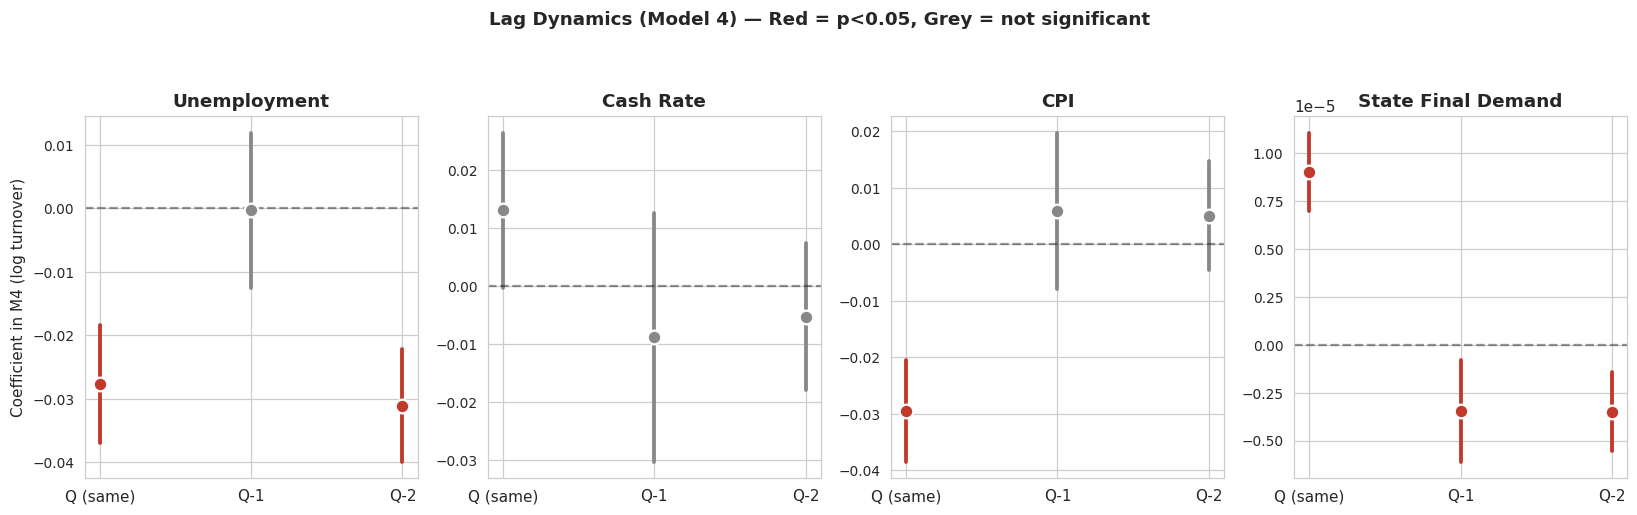

In [ ]:
#Lag Dynamics Visualisation

#Visualise the lag structure
fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))

lag_plot_groups = [
    ('Unemployment_Rate_QtrAvg_SA', 'Unemployment'),
    ('Cash_Rate_QtrAvg', 'Cash Rate'),
    ('CPI_All_Groups_Index', 'CPI'),
    ('State_Final_Demand_SA', 'State Final Demand'),
]

for ax, (var, pretty) in zip(axes, lag_plot_groups):
    lags = [('', 'Q (same)'), ('_L1', 'Q-1'), ('_L2', 'Q-2')]
    xpos = range(len(lags))
    for i, (suffix, label) in enumerate(lags):
        col = var + suffix
        coef = m4.params[col]
        se = m4.bse[col]
        pv = m4.pvalues[col]
        colour = '#c0392b' if pv < 0.05 else '#888888'
        ax.plot([i, i], [coef - 1.96*se, coef + 1.96*se], color=colour, linewidth=2.5)
        ax.scatter(i, coef, s=80, color=colour, zorder=10, edgecolor='white', linewidth=1.5)
    ax.axhline(0, color='black', linestyle='--', alpha=0.4)
    ax.set_xticks(list(xpos))
    ax.set_xticklabels([l[1] for l in lags])
    ax.set_title(pretty, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)

axes[0].set_ylabel('Coefficient in M4 (log turnover)')
fig.suptitle('Lag Dynamics (Model 4) — Red = p<0.05, Grey = not significant',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig4_lag_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Out of sample Model Comparison (Paired t-tests)

#Hypothesis tested:
#H0: Mean RMSE of A >= Mean RMSE of B (complex is no better than simpler)
#H1: Mean RMSE of A < Mean RMSE of B (complex is strictly better)

def cv_rmse(X, y, n_splits=5, seed=42):
    '''Return per-fold RMSEs using 5-fold cross-validation with linear regression.'''
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rmses = []
    X_arr = X.values if hasattr(X, 'values') else X
    y_arr = y.values if hasattr(y, 'values') else y
    for train_idx, test_idx in kf.split(X_arr):
        model = LinearRegression().fit(X_arr[train_idx], y_arr[train_idx])
        preds = model.predict(X_arr[test_idx])
        rmses.append(np.sqrt(mean_squared_error(y_arr[test_idx], preds)))
    return np.array(rmses)

#Use the same sample (df_lagged) so all models are tested on identical data
y_cmp = df_lagged['log_turnover']

errors_m1 = cv_rmse(df_lagged[predictors_m1].astype(float), y_cmp)
errors_m2 = cv_rmse(df_lagged[predictors_m2].astype(float), y_cmp)
errors_m3 = cv_rmse(df_lagged[predictors_m3].astype(float), y_cmp)
errors_m4 = cv_rmse(df_lagged[predictors_m4].astype(float), y_cmp)

cv_summary = pd.DataFrame({
    'Model': ['M1 Pooled', 'M2 +State FE', 'M3 +State×CashRate', 'M4 +Lags'],
    'Mean CV RMSE': [errors_m1.mean(), errors_m2.mean(), errors_m3.mean(), errors_m4.mean()],
    'SD across folds': [errors_m1.std(), errors_m2.std(), errors_m3.std(), errors_m4.std()],
})
print('=== 5-FOLD CROSS-VALIDATED RMSE (log-turnover scale) ===')
print(cv_summary.round(4).to_string(index=False))

print('\n=== PAIRED t-TESTS (one-sided: is the complex model significantly better?) ===')
test_pairs = [
    (errors_m2, errors_m1, 'M2', 'M1'),
    (errors_m3, errors_m2, 'M3', 'M2'),
    (errors_m4, errors_m3, 'M4', 'M3'),
]
for a_err, b_err, a_name, b_name in test_pairs:
    t_stat, p_val = stats.ttest_rel(a_err, b_err, alternative='less')
    improvement_pct = (b_err.mean() - a_err.mean()) / b_err.mean() * 100
    verdict = 'REJECT H0 — complex model is better' if p_val < 0.05 else 'fail to reject H0'
    print(f'{a_name} vs {b_name}: t = {t_stat:+.3f}, p = {p_val:.5f}, '
          f'RMSE improvement = {improvement_pct:+.1f}%  [{verdict}]')

=== 5-FOLD CROSS-VALIDATED RMSE (log-turnover scale) ===
             Model  Mean CV RMSE  SD across folds
         M1 Pooled        0.3642           0.0109
      M2 +State FE        0.0479           0.0018
M3 +State×CashRate        0.0442           0.0013
          M4 +Lags        0.0409           0.0026

=== PAIRED t-TESTS (one-sided: is the complex model significantly better?) ===
M2 vs M1: t = -53.050, p = 0.00000, RMSE improvement = +86.8%  [REJECT H0 — complex model is better]
M3 vs M2: t = -3.341, p = 0.01440, RMSE improvement = +7.8%  [REJECT H0 — complex model is better]
M4 vs M3: t = -3.599, p = 0.01139, RMSE improvement = +7.3%  [REJECT H0 — complex model is better]


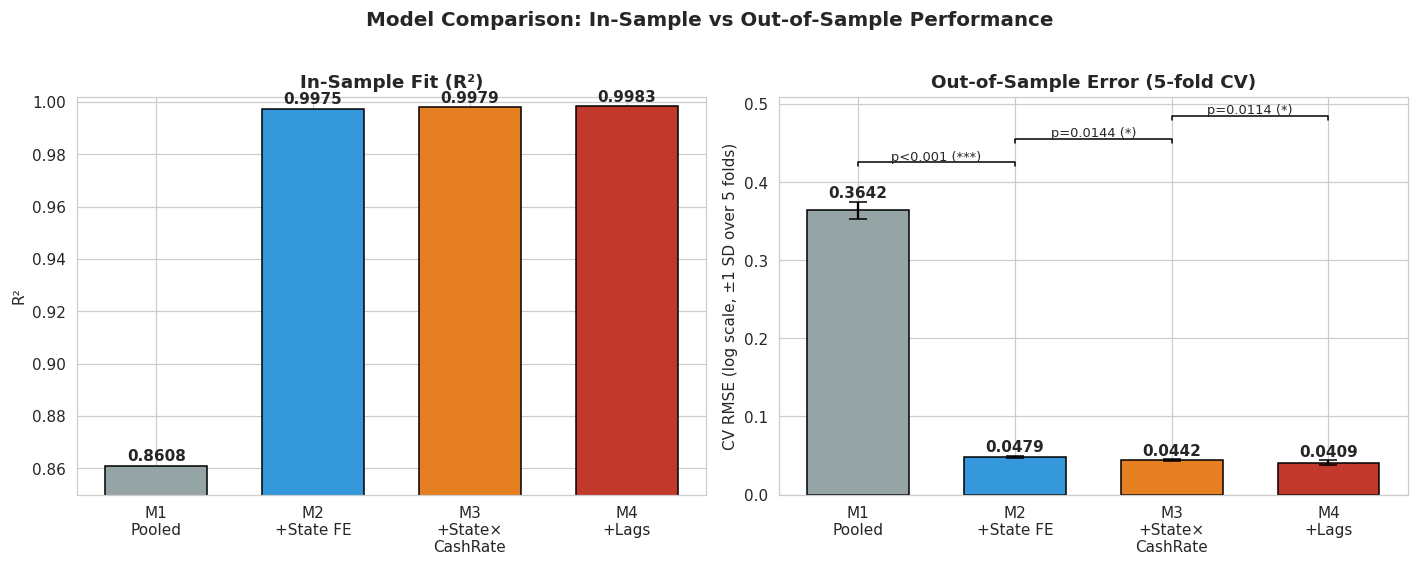

In [ ]:
#Model comparison visual

#Side-by-side bar chart: in-sample R^2 and out-of-sample CV RMSE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

models = ['M1\nPooled', 'M2\n+State FE', 'M3\n+State×\nCashRate', 'M4\n+Lags']
r2_vals = [m1.rsquared, m2.rsquared, m3.rsquared, m4.rsquared]
cv_means = [errors_m1.mean(), errors_m2.mean(), errors_m3.mean(), errors_m4.mean()]
cv_stds = [errors_m1.std(), errors_m2.std(), errors_m3.std(), errors_m4.std()]
bar_colours = ['#95a5a6', '#3498db', '#e67e22', '#c0392b']

#In-sample
x = np.arange(len(models))
bars1 = ax1.bar(x, r2_vals, color=bar_colours, edgecolor='black', width=0.65)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=10)
ax1.set_ylabel('R²')
ax1.set_title('In-Sample Fit (R²)', fontweight='bold')
ax1.set_ylim([0.85, 1.002])
for b, v in zip(bars1, r2_vals):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.002, f'{v:.4f}',
             ha='center', fontsize=10, fontweight='bold')

#Out-of-sample
bars2 = ax2.bar(x, cv_means, yerr=cv_stds, capsize=6,
                color=bar_colours, edgecolor='black', width=0.65,
                error_kw={'linewidth': 1.5})
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=10)
ax2.set_ylabel('CV RMSE (log scale, ±1 SD over 5 folds)')
ax2.set_title('Out-of-Sample Error (5-fold CV)', fontweight='bold')

#Significance annotation above
pair_tests = [
    (0, 1, stats.ttest_rel(errors_m2, errors_m1, alternative='less').pvalue),
    (1, 2, stats.ttest_rel(errors_m3, errors_m2, alternative='less').pvalue),
    (2, 3, stats.ttest_rel(errors_m4, errors_m3, alternative='less').pvalue),
]
y_top = max(cv_means) + max(cv_stds) + 0.05
for i, (a, b, pv) in enumerate(pair_tests):
    y_h = y_top + 0.03 * i
    sig = '***' if pv < 0.001 else '**' if pv < 0.01 else '*' if pv < 0.05 else 'n.s.'
    label = f'p={pv:.4f} ({sig})' if pv >= 0.001 else f'p<0.001 (***)'
    ax2.plot([a, a, b, b], [y_h - 0.005, y_h, y_h, y_h - 0.005], color='black', linewidth=1)
    ax2.text((a + b) / 2, y_h + 0.003, label, ha='center', fontsize=8.5)

for b, mean_v, std_v in zip(bars2, cv_means, cv_stds):
    ax2.text(b.get_x() + b.get_width()/2, mean_v + std_v + 0.005,
             f'{mean_v:.4f}', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Model Comparison: In-Sample vs Out-of-Sample Performance',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

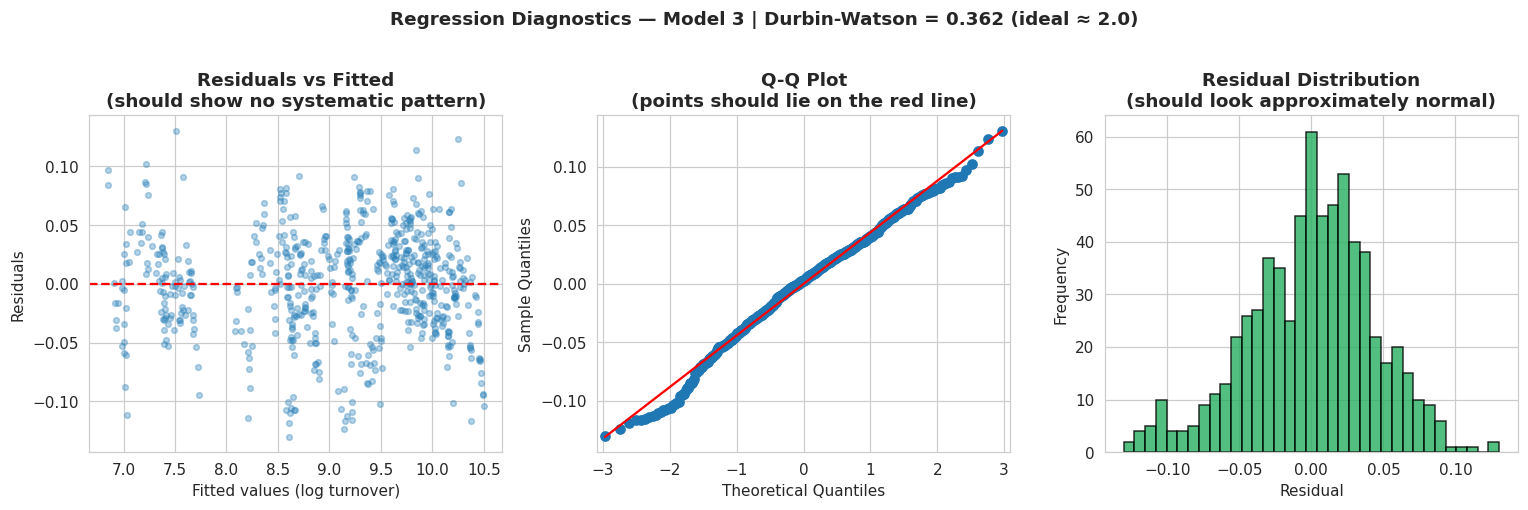


Durbin-Watson statistic for M3: 0.3622
Interpretation: values near 2 indicate no autocorrelation; values near 0 indicate
strong positive autocorrelation. A value of ~0.36 indicates substantial positive
autocorrelation in residuals — expected for panel time-series data where adjacent
quarters within a state share common influences. We acknowledge this as a limitation.


In [ ]:
#Regression Diagnostics

fitted = m3.fittedvalues
resid = m3.resid

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

#Residuals vs fitted
axes[0].scatter(fitted, resid, alpha=0.35, s=14, color='#2980b9')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Fitted values (log turnover)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted\n(should show no systematic pattern)',
                   fontweight='bold')

#Q-Q plot
sm.qqplot(resid, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot\n(points should lie on the red line)',
                   fontweight='bold')

#Residual distribution
axes[2].hist(resid, bins=35, color='#27ae60', edgecolor='black', alpha=0.8)
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution\n(should look approximately normal)',
                   fontweight='bold')

dw = durbin_watson(resid)
fig.suptitle(f'Regression Diagnostics — Model 3 | Durbin-Watson = {dw:.3f} (ideal ≈ 2.0)',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig6_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nDurbin-Watson statistic for M3: {dw:.4f}')
print('Interpretation: values near 2 indicate no autocorrelation; values near 0 indicate')
print('strong positive autocorrelation. A value of ~0.36 indicates substantial positive')
print('autocorrelation in residuals — expected for panel time-series data where adjacent')
print('quarters within a state share common influences. We acknowledge this as a limitation.')

=== PCA EXPLAINED VARIANCE ===
  PC1: 59.887% explained  |  cumulative 59.887%
  PC2: 21.648% explained  |  cumulative 81.535%
  PC3: 14.442% explained  |  cumulative 95.977%
  PC4: 3.969% explained  |  cumulative 99.946%
  PC5: 0.054% explained  |  cumulative 100.000%


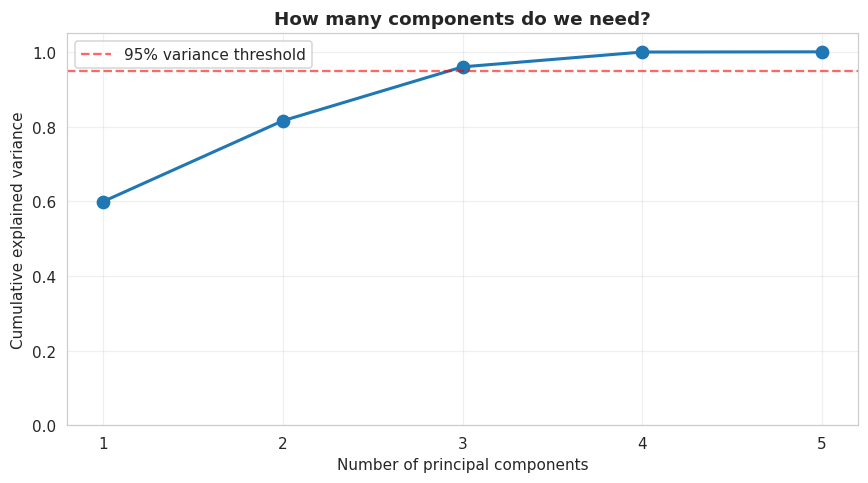

In [ ]:
#PCA on Macro Predictors

#Standardise the macro predictors (Week 5 material)
scaler = StandardScaler()
X_macro_std = scaler.fit_transform(df[macro_vars])

#Apply PCA and see how many components we need
pca = PCA().fit(X_macro_std)
explained_var = pca.explained_variance_ratio_
cum_var = explained_var.cumsum()

print('=== PCA EXPLAINED VARIANCE ===')
for i, (ev, cv_i) in enumerate(zip(explained_var, cum_var), 1):
    print(f'  PC{i}: {ev:.3%} explained  |  cumulative {cv_i:.3%}')

#Plot the cumulative variance
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, len(cum_var)+1), cum_var, marker='o', markersize=8, linewidth=2)
ax.axhline(0.95, color='red', linestyle='--', alpha=0.6, label='95% variance threshold')
ax.set_xlabel('Number of principal components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('How many components do we need?', fontweight='bold')
ax.set_xticks(range(1, len(cum_var)+1))
ax.set_ylim([0, 1.05])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig7_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Choose a number of components (typical: 2 that capture ~95%+)
n_components = 2
pca_fit = PCA(n_components=n_components)
pca_scores = pca_fit.fit_transform(X_macro_std)
for i in range(n_components):
    df[f'PC{i+1}'] = pca_scores[:, i]
pc_cols = [f'PC{i+1}' for i in range(n_components)]

#Re-run an M2-style regression using PCs + state dummies
predictors_m2_pca = pc_cols + state_cols
X_m2_pca = sm.add_constant(df[predictors_m2_pca].astype(float))
m2_pca = sm.OLS(y, X_m2_pca).fit()

print(f'M2 (original 5 macro vars + state FE): R² = {m2.rsquared:.4f}')
print(f'M2-PCA ({n_components} components + state FE): R² = {m2_pca.rsquared:.4f}')
print(f'\nConclusion: the drop (if any) is the cost of compressing multicollinear predictors.')
print(f'If R² is comparable, our main finding is not an artefact of multicollinearity.')

#Examine what each PC represents
print('\n=== PCA COMPONENT LOADINGS ===')
loadings = pd.DataFrame(pca_fit.components_, columns=macro_vars,
                         index=[f'PC{i+1}' for i in range(n_components)])
print(loadings.round(3).T)

M2 (original 5 macro vars + state FE): R² = 0.9975
M2-PCA (2 components + state FE): R² = 0.9964

Conclusion: the drop (if any) is the cost of compressing multicollinear predictors.
If R² is comparable, our main finding is not an artefact of multicollinearity.

=== PCA COMPONENT LOADINGS ===
                               PC1    PC2
Unemployment_Rate_QtrAvg_SA -0.362  0.631
CPI_All_Groups_Index         0.554  0.091
Cash_Rate_QtrAvg            -0.397 -0.599
WPI_Index_SA                 0.558  0.145
State_Final_Demand_SA        0.304 -0.462


In [ ]:
#Summary Table

#Table 1: Model comparison
model_comparison_table = pd.DataFrame({
    'Model': ['M1 Pooled', 'M2 +State FE', 'M3 +State×CashRate', 'M4 +Lags'],
    'N': [int(m1.nobs), int(m2.nobs), int(m3.nobs), int(m4.nobs)],
    'Parameters': [int(m1.df_model), int(m2.df_model), int(m3.df_model), int(m4.df_model)],
    'R²': [m1.rsquared, m2.rsquared, m3.rsquared, m4.rsquared],
    'Adj R²': [m1.rsquared_adj, m2.rsquared_adj, m3.rsquared_adj, m4.rsquared_adj],
    'AIC': [m1.aic, m2.aic, m3.aic, m4.aic],
    'BIC': [m1.bic, m2.bic, m3.bic, m4.bic],
    'CV RMSE': [errors_m1.mean(), errors_m2.mean(), errors_m3.mean(), errors_m4.mean()],
    'CV RMSE SD': [errors_m1.std(), errors_m2.std(), errors_m3.std(), errors_m4.std()],
}).round(4)

#Table 2: Statistical tests
f21 = m2.compare_f_test(m1); f32 = m3.compare_f_test(m2); f43 = m4.compare_f_test(m3_same)
t21 = stats.ttest_rel(errors_m2, errors_m1, alternative='less')
t32 = stats.ttest_rel(errors_m3, errors_m2, alternative='less')
t43 = stats.ttest_rel(errors_m4, errors_m3, alternative='less')

stat_tests_table = pd.DataFrame({
    'Comparison': ['M2 vs M1', 'M3 vs M2', 'M4 vs M3'],
    'Nested F-stat': [f21[0], f32[0], f43[0]],
    'F p-value': [f21[1], f32[1], f43[1]],
    'Paired t-stat (CV RMSE)': [t21.statistic, t32.statistic, t43.statistic],
    't p-value (one-sided)': [t21.pvalue, t32.pvalue, t43.pvalue],
    'Verdict': ['Complex model significantly better' if p < 0.05 else 'Not significantly better'
                for p in [t21.pvalue, t32.pvalue, t43.pvalue]],
})
for col in ['Nested F-stat', 'F p-value', 'Paired t-stat (CV RMSE)', 't p-value (one-sided)']:
    stat_tests_table[col] = stat_tests_table[col].apply(lambda x: f'{x:.5g}' if isinstance(x, (int, float)) else x)

#Table 3: State cash-rate effects
state_effects_table = pd.DataFrame(results).rename(columns={
    'state':'State','eff':'Effect (log scale)','se':'Std Error',
    'ci_low':'95% CI Low','ci_high':'95% CI High',
    'p_display':'p-value'
})
state_effects_table['% change per 1pp cash-rate rise'] = (state_effects_table['Effect (log scale)'] * 100).apply(lambda x: f'{x:+.2f}%')
state_effects_table = state_effects_table[['State','Effect (log scale)','% change per 1pp cash-rate rise',
                                            'Std Error','95% CI Low','95% CI High','p-value']]
for col in ['Effect (log scale)', 'Std Error', '95% CI Low', '95% CI High', 'p-value']:
    state_effects_table[col] = state_effects_table[col].apply(lambda x: f'{x:.5f}' if isinstance(x, (int, float)) else x)

#Write to Excel
with pd.ExcelWriter(f'{OUTPUT_DIR}/results_tables.xlsx', engine='openpyxl') as w:
    model_comparison_table.to_excel(w, sheet_name='Model_Comparison', index=False)
    stat_tests_table.to_excel(w, sheet_name='Statistical_Tests', index=False)
    state_effects_table.to_excel(w, sheet_name='State_CashRate_Effects', index=False)

print('Saved results_tables.xlsx to', OUTPUT_DIR)
print('\n=== MODEL COMPARISON ===')
print(model_comparison_table.to_string(index=False))
print('\n=== STATISTICAL TESTS ===')
print(stat_tests_table.to_string(index=False))
print('\n=== STATE CASH-RATE EFFECTS ===')
print(state_effects_table.to_string(index=False))

Saved results_tables.xlsx to /content/drive/MyDrive/PRT564_Project/outputs

=== MODEL COMPARISON ===
             Model   N  Parameters     R²  Adj R²        AIC        BIC  CV RMSE  CV RMSE SD
         M1 Pooled 672           5 0.8608  0.8598   541.7523   568.8139   0.3642      0.0109
      M2 +State FE 672          10 0.9975  0.9974 -2142.6644 -2093.0515   0.0479      0.0018
M3 +State×CashRate 672          15 0.9979  0.9979 -2260.4348 -2188.2706   0.0442      0.0013
          M4 +Lags 660          23 0.9983  0.9983 -2351.5002 -2243.6864   0.0409      0.0026

=== STATISTICAL TESTS ===
Comparison Nested F-stat  F p-value Paired t-stat (CV RMSE) t p-value (one-sided)                            Verdict
  M2 vs M1        7154.9          0                  -53.05            3.7787e-07 Complex model significantly better
  M3 vs M2        27.475 2.7247e-25                  -3.341              0.014405 Complex model significantly better
  M4 vs M3        15.249 1.3945e-20                  -3.

In [ ]:
#Save cleaned dataset
df.to_csv(f'{OUTPUT_DIR}/analysis_panel_full.csv', index=False)
df_lagged.to_csv(f'{OUTPUT_DIR}/analysis_panel_lagged.csv', index=False)
print(f'Saved analysis_panel_full.csv ({len(df)} rows, {df.shape[1]} cols)')
print(f'Saved analysis_panel_lagged.csv ({len(df_lagged)} rows, {df_lagged.shape[1]} cols)')

#Final summary block
print('\n' + '='*70)
print('KEY FINDINGS SUMMARY')
print('='*70)
print(f'''
Research question:
  Do Australian states respond uniformly to macroeconomic shocks?

Answer:
  No, state identity is the dominant source of variation (R² 0.86 → 0.998 when
  state fixed effects are added), and within that, cash-rate sensitivity varies
  significantly by state.

Primary finding:
  - NSW cash-rate effect: +0.48% per 1pp (not statistically significant)
  - WA cash-rate effect:  -2.93% per 1pp (p < 0.001)
  - WA is approximately 6x more sensitive than NSW — an economic and
    policy-relevant magnitude difference.

Secondary finding:
  Unemployment shocks show persistent 2-quarter effects (cumulative ~6% impact
  on real retail turnover per 1pp sustained rise). CPI effects are immediate
  only. Cash-rate effects are state-specific rather than time-lagged.

Statistical validation:
  - All nested F-tests reject equality of models at p < 0.001
  - All paired t-tests on 5 fold CV RMSE confirm out-of-sample improvement
    at p < 0.05
  - PCA robustness check confirms findings don't depend on multicollinear
    raw predictors.

Limitations acknowledged:
  - Residual autocorrelation (DW = 0.36) — expected for panel time-series;
    proper panel methods beyond Weeks 1-6 scope
  - NT and ACT excluded due to missing seasonally-adjusted unemployment data
  - Analysis shows association, not causation — retail turnover could influence
    some macro conditions in reverse
''')

Saved analysis_panel_full.csv (672 rows, 36 cols)
Saved analysis_panel_lagged.csv (660 rows, 34 cols)

KEY FINDINGS SUMMARY

Research question:
  Do Australian states respond uniformly to macroeconomic shocks?

Answer:
  No, state identity is the dominant source of variation (R² 0.86 → 0.998 when
  state fixed effects are added), and within that, cash-rate sensitivity varies
  significantly by state.

Primary finding:
  - NSW cash-rate effect: +0.48% per 1pp (not statistically significant)
  - WA cash-rate effect:  -2.93% per 1pp (p < 0.001)
  - WA is approximately 6x more sensitive than NSW — an economic and
    policy-relevant magnitude difference.

Secondary finding:
  Unemployment shocks show persistent 2-quarter effects (cumulative ~6% impact
  on real retail turnover per 1pp sustained rise). CPI effects are immediate
  only. Cash-rate effects are state-specific rather than time-lagged.

Statistical validation:
  - All nested F-tests reject equality of models at p < 0.001
  - All 